In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: []


In [ ]:
dataset_path="/content/drive/MyDrive/brain tumer/archive"

In [ ]:
train_path = os.path.join(dataset_path, "Training")
test_path = os.path.join(dataset_path, "Testing")

In [ ]:
print("Training Classes:")
print(os.listdir(train_path))

print("\nTesting Classes:")
print(os.listdir(test_path))

Training Classes:
['notumor', 'meningioma', 'pituitary', 'glioma']

Testing Classes:
['meningioma', 'glioma', 'pituitary', 'notumor']


In [ ]:
for folder in os.listdir(train_path):

    folder_path = os.path.join(train_path, folder)

    print(folder, ":", len(os.listdir(folder_path)), "images")

notumor : 1400 images
meningioma : 1400 images
pituitary : 1400 images
glioma : 1400 images


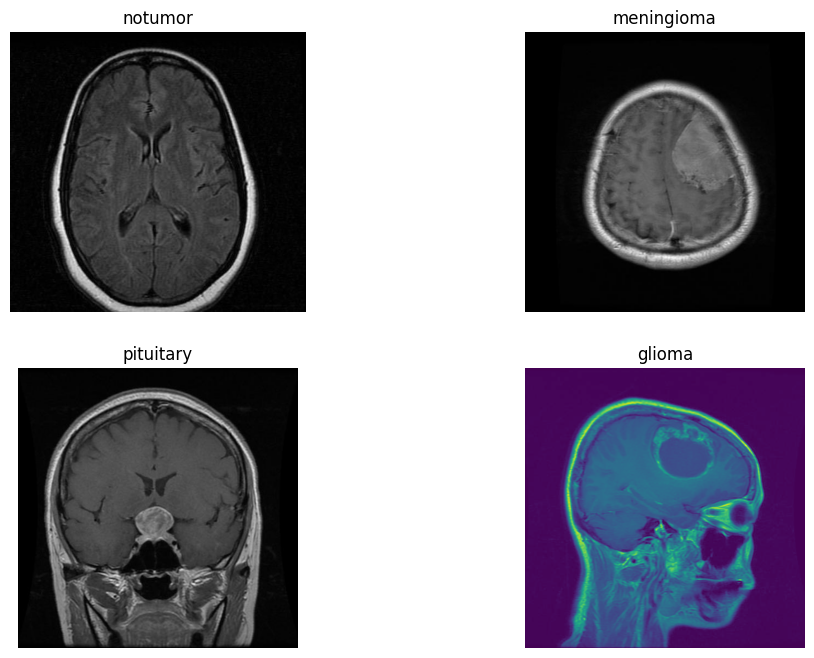

In [ ]:
from PIL import Image

classes = os.listdir(train_path)

plt.figure(figsize=(12,8))

for i, cls in enumerate(classes):

    img_path = os.path.join(
        train_path,
        cls,
        os.listdir(os.path.join(train_path, cls))[0]
    )

    img = Image.open(img_path)

    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

In [ ]:
#Normalize pixel values.

train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=20,

    zoom_range=0.2,

    horizontal_flip=True,

    validation_split=0.2

)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [ ]:
train_generator = train_datagen.flow_from_directory(

    train_path,

    target_size=(224,224),

    batch_size=32,

    class_mode='categorical',

    subset='training'

)

val_generator = train_datagen.flow_from_directory(

    train_path,

    target_size=(224,224),

    batch_size=32,

    class_mode='categorical',

    subset='validation'

)

test_generator = test_datagen.flow_from_directory(

    test_path,

    target_size=(224,224),

    batch_size=32,

    class_mode='categorical',

    shuffle=False

)

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [ ]:
print(train_generator.class_indices)

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


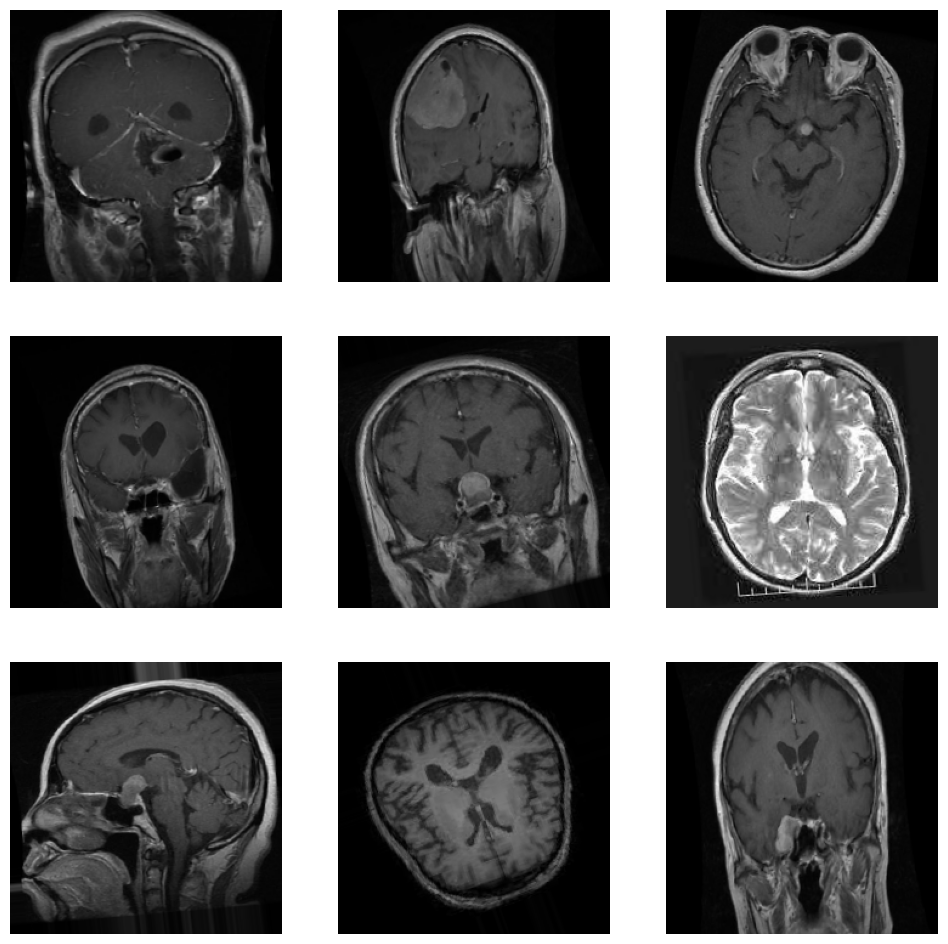

In [ ]:
images, labels = next(train_generator)

plt.figure(figsize=(12,12))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    plt.axis("off")

plt.show()

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.optimizers import Adam

In [ ]:
base_model = VGG16(

    weights='imagenet',

    include_top=False,

    input_shape=(224,224,3)

)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
#pretrained VGG16 weights will not be updated during the initial training
# base_model.trainable = False
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

In [ ]:
model = Sequential([

    base_model,

    Flatten(),

    Dense(256,activation='relu'),

    Dropout(0.5),

    Dense(4,activation='softmax')

])

In [ ]:
model.compile(

    optimizer=Adam(learning_rate=0.0001),

    loss='categorical_crossentropy',

    metrics=['accuracy']

)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,138,500 (80.64 MB)

 Trainable params: 21,138,500 (80.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(

    train_generator,

    validation_data=val_generator,

    epochs=10

)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 2358s 17s/step - accuracy: 0.6000 - loss: 0.9334 - val_accuracy: 0.7437 - val_loss: 0.6021
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 112s 797ms/step - accuracy: 0.8319 - loss: 0.4476 - val_accuracy: 0.8902 - val_loss: 0.2894
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 113s 806ms/step - accuracy: 0.9027 - loss: 0.2882 - val_accuracy: 0.8679 - val_loss: 0.3540
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 112s 799ms/step - accuracy: 0.9141 - loss: 0.2492 - val_accuracy: 0.9205 - val_loss: 0.2118
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 112s 799ms/step - accuracy: 0.9379 - loss: 0.1865 - val_accuracy: 0.9375 - val_loss: 0.1770
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 113s 802ms/step - accuracy: 0.9449 - loss: 0.1524 - val_accuracy: 0.9152 - val_loss: 0.2645
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 115s 819ms/step - accuracy: 0.9529 - loss: 0.1323 - val_accuracy: 0.9473 - val_loss: 0.1343
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 113s 803ms/step - accuracy: 0.9616 - 

In [ ]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Accuracy :", test_accuracy)

50/50 ━━━━━━━━━━━━━━━━━━━━ 641s 13s/step - accuracy: 0.9194 - loss: 0.4240
Test Accuracy : 0.9193750023841858


In [ ]:
model.save("VGG16_Brain_Tumor.keras")

In [ ]:
import os
print(os.path.exists("VGG16_Brain_Tumor.keras"))

True


In [ ]:
from google.colab import files
files.download("VGG16_Brain_Tumor.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(model.input_shape)
print(train_generator.class_indices)

(None, 224, 224, 3)
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


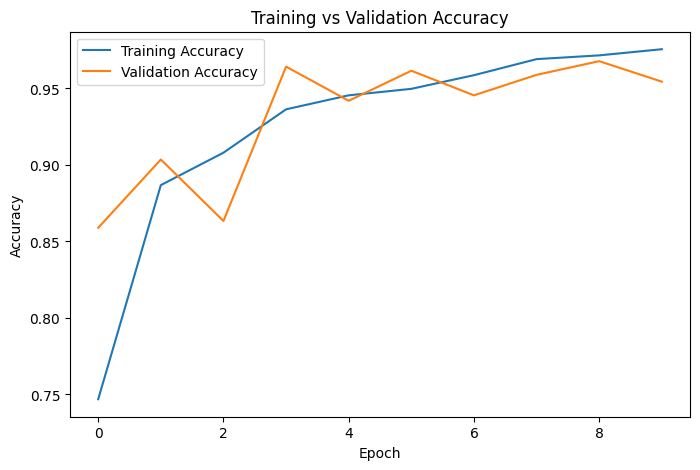

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()

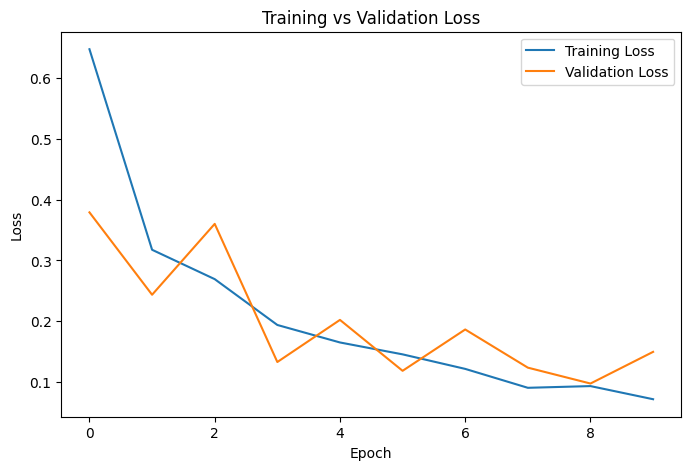

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

In [ ]:
# from tensorflow.keras.preprocessing.image import ImageDataGenerator

# # -----------------------------
# # Training augmentation
# # -----------------------------
# train_datagen = ImageDataGenerator(
#     rescale=1./255,
#     rotation_range=15,
#     width_shift_range=0.10,
#     height_shift_range=0.10,
#     zoom_range=0.15,
#     horizontal_flip=True,
#     fill_mode='nearest',
#     validation_split=0.20
# )

# # -----------------------------
# # Validation - NO augmentation
# # -----------------------------
# val_datagen = ImageDataGenerator(
#     rescale=1./255
# )

# # -----------------------------
# # Test - NO augmentation
# # -----------------------------
# test_datagen = ImageDataGenerator(
#     rescale=1./255
# )

In [ ]:
# train_generator = train_datagen.flow_from_directory(
#     train_path,
#     target_size=(224, 224),
#     batch_size=32,
#     class_mode='categorical',
#     subset='training',
#     shuffle=True,
#     seed=42
# )

Found 4480 images belonging to 4 classes.


In [ ]:
# test_generator = test_datagen.flow_from_directory(
#     test_path,
#     target_size=(224, 224),
#     batch_size=32,
#     class_mode='categorical',
#     shuffle=False
# )

# num_classes = train_generator.num_classes

# print("Classes:", train_generator.class_indices)
# print("Number of classes:", num_classes)

Found 1600 images belonging to 4 classes.
Classes: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Number of classes: 4


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

image_size = 224
patch_size = 16

num_patches = (image_size // patch_size) ** 2

projection_dim = 64
num_heads = 4

transformer_layers = 4

transformer_units = [
    projection_dim * 2,
    projection_dim
]

dropout_rate = 0.2

In [ ]:
class Patches(layers.Layer):

    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):

        batch_size = tf.shape(images)[0]

        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding='VALID'
        )

        patch_dims = patches.shape[-1]

        patches = tf.reshape(
            patches,
            [batch_size, -1, patch_dims]
        )

        return patches

In [ ]:
class PatchEncoder(layers.Layer):

    def __init__(self, num_patches, projection_dim):
        super().__init__()

        self.num_patches = num_patches

        self.projection = layers.Dense(projection_dim)

        self.position_embedding = layers.Embedding(
            input_dim=num_patches,
            output_dim=projection_dim
        )

    def call(self, patches):

        positions = tf.range(
            start=0,
            limit=self.num_patches,
            delta=1
        )

        encoded = (
            self.projection(patches)
            + self.position_embedding(positions)
        )

        return encoded

In [ ]:
inputs = layers.Input(
    shape=(224, 224, 3)
)

# -----------------------------
# Patch extraction
# -----------------------------

patches = Patches(patch_size)(inputs)

# -----------------------------
# Patch encoding
# -----------------------------

encoded_patches = PatchEncoder(
    num_patches,
    projection_dim
)(patches)

In [ ]:
for _ in range(transformer_layers):

    # Layer Normalization
    x1 = layers.LayerNormalization(
        epsilon=1e-6
    )(encoded_patches)

    # Multi-Head Self Attention
    attention_output = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=projection_dim,
        dropout=dropout_rate
    )(
        x1,
        x1
    )

    # Residual connection
    x2 = layers.Add()([
        attention_output,
        encoded_patches
    ])

    # Layer Normalization
    x3 = layers.LayerNormalization(
        epsilon=1e-6
    )(x2)

    # Feed Forward Network
    x3 = layers.Dense(
        transformer_units[0],
        activation=tf.nn.gelu
    )(x3)

    x3 = layers.Dropout(
        dropout_rate
    )(x3)

    x3 = layers.Dense(
        transformer_units[1]
    )(x3)

    x3 = layers.Dropout(
        dropout_rate
    )(x3)

    # Residual connection
    encoded_patches = layers.Add()([
        x3,
        x2
    ])

In [ ]:
num_classes = train_generator.num_classes

print("Number of classes:", num_classes)
print("Classes:", train_generator.class_indices)

Number of classes: 4
Classes: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [ ]:
representation = layers.LayerNormalization(
    epsilon=1e-6
)(encoded_patches)

representation = layers.Flatten()(
    representation
)

representation = layers.Dropout(
    0.5
)(representation)

representation = layers.Dense(
    256,
    activation='relu'
)(representation)

representation = layers.Dropout(
    0.5
)(representation)

outputs = layers.Dense(
    num_classes,
    activation='softmax'
)(representation)

model = Model(
    inputs=inputs,
    outputs=outputs
)

In [ ]:
model.compile(
    optimizer = tf.keras.optimizers.AdamW(
    learning_rate=1e-4,
    weight_decay=1e-4
    ),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patches_2 (Patches) │ (None, None, 768) │          0 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder_2     │ (None, 196, 64)   │     61,760 │ patches_2[0][0]   │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ patch_encoder_2[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 196, 64)   │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_16 (Add)        │ (None, 196, 64)   │          0 │ multi_head_atten… │
│                     │                   │            │ patch_encoder_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ add_16[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 196, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_27          │ (None, 196, 128)  │          0 │ dense_21[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 196, 64)   │      8,256 │ dropout_27[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_28          │ (None, 196, 64)   │          0 │ dense_22[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_17 (Add)        │ (None, 196, 64)   │          0 │ dropout_28[0][0], │
│                     │                   │            │ add_16[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ add_17[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 196, 64)   │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_18 (Add)        │ (None, 196, 64)   │          0 │ multi_head_atten… │
│                     │                   │            │ add_17[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ add_18[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 196, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_30          │ (None, 196, 128)  │          0 │ dense_23[0][0]    │
│ (Dropout)           │                   │            │                 

 Total params: 3,607,236 (13.76 MB)

 Trainable params: 3,607,236 (13.76 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

callbacks = [

    EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-7
    ),

    ModelCheckpoint(
        'best_vit_model.keras',
        monitor='val_accuracy',
        save_best_only=True
    )
]

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 113s 619ms/step - accuracy: 0.4116 - loss: 1.4951 - precision: 0.4694 - recall: 0.2692 - val_accuracy: 0.5420 - val_loss: 1.0703 - val_precision: 0.7587 - val_recall: 0.2920 - learning_rate: 1.0000e-04
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 84s 600ms/step - accuracy: 0.5221 - loss: 1.1201 - precision: 0.6455 - recall: 0.3402 - val_accuracy: 0.5893 - val_loss: 0.9800 - val_precision: 0.7045 - val_recall: 0.4429 - learning_rate: 1.0000e-04
Epoch 3/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 83s 595ms/step - accuracy: 0.5853 - loss: 1.0172 - precision: 0.6955 - recall: 0.4150 - val_accuracy: 0.5688 - val_loss: 1.0055 - val_precision: 0.6654 - val_recall: 0.4545 - learning_rate: 1.0000e-04
Epoch 4/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 83s 592ms/step - accuracy: 0.5958 - loss: 1.0234 - precision: 0.6958 - recall: 0.4145 - val_accuracy: 0.5277 - val_loss: 1.0849 - val_precision: 0.5993 - val_recall: 0.4366 - learning_rate: 1.0000e-04
Epoch 5/50
140/140 ━━━━━━━━━━━━━━━━

In [ ]:
test_generator.reset()

test_results = model.evaluate(
    test_generator,
    verbose=1
)

print("Test Loss:", test_results[0])
print("Test Accuracy:", test_results[1])
print("Test Precision:", test_results[2])
print("Test Recall:", test_results[3])

50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 116ms/step - accuracy: 0.6806 - loss: 1.1178 - precision: 0.7050 - recall: 0.6513
Test Loss: 1.117807149887085
Test Accuracy: 0.6806250214576721
Test Precision: 0.7050067782402039
Test Recall: 0.6512500047683716


In [ ]:
import numpy as np
from sklearn.metrics import classification_report

test_generator.reset()

predictions = model.predict(
    test_generator
)

y_pred = np.argmax(
    predictions,
    axis=1
)

y_true = test_generator.classes

class_names = list(
    test_generator.class_indices.keys()
)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 109ms/step
              precision    recall  f1-score   support

      glioma       0.62      0.65      0.64       400
  meningioma       0.60      0.30      0.41       400
     notumor       0.65      0.91      0.76       400
   pituitary       0.81      0.86      0.83       400

    accuracy                           0.68      1600
   macro avg       0.67      0.68      0.66      1600
weighted avg       0.67      0.68      0.66      1600



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

[[260  50  72  18]
 [117 122 109  52]
 [ 14  13 363  10]
 [ 27  17  12 344]]
